# NB06: Temporal Trends + BacDive Classification

**Goal**: Analyze temporal trends in AMR gene counts and compare BacDive
hierarchical environment classification with NCBI keyword-based classification.

**Compute**: Local (10-20 min)

**Inputs**: `data/genome_amr_matrices/*.tsv`, `data/genome_metadata.csv`

**Outputs**:
- `data/temporal_amr_trends.csv` — per-species temporal regression results
- `data/bacdive_amr_bridge.csv` — species-level BacDive + NCBI environment comparison

In [1]:
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = Path(os.getcwd()).parent
ATLAS_DIR = PROJECT_DIR.parent / 'amr_pangenome_atlas'
DATA_DIR = PROJECT_DIR / 'data'
MATRIX_DIR = DATA_DIR / 'genome_amr_matrices'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Parse Collection Dates

In [2]:
genome_meta = pd.read_csv(DATA_DIR / 'genome_metadata.csv')
print(f"Genomes with metadata: {len(genome_meta)}")

def parse_year(date_str):
    """Extract year from collection_date (handles various NCBI formats)."""
    if pd.isna(date_str):
        return np.nan
    s = str(date_str).strip()
    
    # Try common patterns
    # YYYY-MM-DD or YYYY-MM or YYYY
    m = re.match(r'(\d{4})', s)
    if m:
        year = int(m.group(1))
        if 1900 <= year <= 2026:
            return year
    
    # DD-Mon-YYYY or Mon-YYYY
    m = re.search(r'(\d{4})$', s)
    if m:
        year = int(m.group(1))
        if 1900 <= year <= 2026:
            return year
    
    return np.nan

genome_meta['year'] = genome_meta['collection_date'].apply(parse_year)
print(f"Genomes with valid year: {genome_meta['year'].notna().sum()}")
print(f"Year range: {genome_meta['year'].min():.0f} - {genome_meta['year'].max():.0f}")
print(f"\nYear distribution (top 10):")
print(genome_meta['year'].value_counts().sort_index().tail(10))

Genomes with metadata: 180025
Genomes with valid year: 106649
Year range: 1900 - 2022

Year distribution (top 10):
year
2013.0     7052
2014.0     9342
2015.0     8996
2016.0    10184
2017.0     9933
2018.0     9734
2019.0     9007
2020.0     4656
2021.0     1791
2022.0      268
Name: count, dtype: int64


## 2. Compute AMR Counts Per Genome

In [3]:
# Build genome -> AMR count mapping from matrices
genome_amr_counts = {}
genome_species = {}

matrix_files = sorted(MATRIX_DIR.glob('*.tsv'))

for mf in matrix_files:
    species_id = mf.stem
    matrix = pd.read_csv(mf, sep='\t', index_col=0)
    counts = matrix.sum(axis=1)
    for gid, cnt in counts.items():
        genome_amr_counts[gid] = cnt
        genome_species[gid] = species_id

genome_meta['amr_count'] = genome_meta['genome_id'].map(genome_amr_counts)
genome_meta['species_id'] = genome_meta['genome_id'].map(genome_species)

dated = genome_meta.dropna(subset=['year', 'amr_count', 'species_id'])
print(f"Genomes with year + AMR count: {len(dated)}")

Genomes with year + AMR count: 106649


## 3. Temporal Regression Per Species

In [4]:
temporal_results = []

for species_id, grp in dated.groupby('species_id'):
    if len(grp) < 20:  # need reasonable sample size
        continue
    if grp['year'].nunique() < 3:  # need temporal spread
        continue
    
    # Filter to reasonable year range (post-1990)
    recent = grp[grp['year'] >= 1990]
    if len(recent) < 20 or recent['year'].nunique() < 3:
        continue
    
    # Linear regression: AMR count ~ year
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        recent['year'], recent['amr_count']
    )
    
    # Spearman for robustness
    rho, rho_p = stats.spearmanr(recent['year'], recent['amr_count'])
    
    short_name = species_id.split('--')[0].replace('s__', '')
    
    temporal_results.append({
        'gtdb_species_clade_id': species_id,
        'species_name': short_name,
        'n_genomes': len(recent),
        'year_range': f"{int(recent['year'].min())}-{int(recent['year'].max())}",
        'slope': slope,
        'r_squared': r_value**2,
        'p_value': p_value,
        'spearman_rho': rho,
        'spearman_p': rho_p,
        'mean_amr': recent['amr_count'].mean(),
    })

temporal_df = pd.DataFrame(temporal_results)

if len(temporal_df) > 0:
    from statsmodels.stats.multitest import multipletests
    _, fdr, _, _ = multipletests(temporal_df['p_value'], method='fdr_bh')
    temporal_df['fdr'] = fdr
    
    temporal_df.to_csv(DATA_DIR / 'temporal_amr_trends.csv', index=False)
    
    sig = temporal_df[temporal_df['fdr'] < 0.05]
    print(f"Species with temporal data: {len(temporal_df)}")
    print(f"Significant trends (FDR < 0.05): {len(sig)}")
    print(f"  Increasing: {(sig['slope'] > 0).sum()}")
    print(f"  Decreasing: {(sig['slope'] < 0).sum()}")
    print(f"\nTop increasing:")
    print(sig.nlargest(5, 'slope')[['species_name', 'slope', 'r_squared', 'n_genomes']].to_string(index=False))
else:
    print("No species had enough temporal data for regression.")

Species with temporal data: 513
Significant trends (FDR < 0.05): 0
  Increasing: 0
  Decreasing: 0

Top increasing:
Empty DataFrame
Columns: [species_name, slope, r_squared, n_genomes]
Index: []


## 4. Rule-Based Environment Classification (BacDive-style)

BacDive provides cat1/cat2/cat3 hierarchical environment classifications.
We match species names to BacDive records.

In [5]:
# Check for BacDive data
bacdive_path = ATLAS_DIR / 'data' / 'bacdive_environments.csv'
bacdive_alt = DATA_DIR / 'bacdive_environments.csv'

# BacDive cat1 categories (broad)
# If we don't have pre-downloaded BacDive data, use rule-based approximation
def classify_env_from_name(species_name):
    """Approximate BacDive cat1 from species name + known ecology."""
    name = species_name.lower().replace('_', ' ')
    
    # Host-associated
    host_indicators = [
        'staphylococcus', 'streptococcus', 'enterococcus', 'haemophilus',
        'neisseria', 'helicobacter', 'campylobacter', 'clostridioides',
        'klebsiella', 'escherichia', 'salmonella', 'shigella',
        'pseudomonas aeruginosa', 'acinetobacter baumannii',
        'mycobacterium tuberculosis', 'legionella', 'listeria',
        'bacteroides', 'bifidobacterium', 'lactobacillus',
        'enterobacter', 'citrobacter', 'proteus', 'serratia',
        'bordetella', 'corynebacterium', 'propionibacterium',
    ]
    for indicator in host_indicators:
        if indicator in name:
            return 'Host-associated'
    
    # Aquatic
    aquatic_indicators = [
        'vibrio', 'shewanella', 'alteromonas', 'marinobacter',
        'photobacterium', 'aliivibrio',
    ]
    for indicator in aquatic_indicators:
        if indicator in name:
            return 'Aquatic'
    
    # Terrestrial/Soil
    soil_indicators = [
        'streptomyces', 'bacillus', 'paenibacillus', 'rhizobium',
        'bradyrhizobium', 'agrobacterium', 'pseudomonas fluorescens',
        'pseudomonas putida', 'pseudomonas syringae',
    ]
    for indicator in soil_indicators:
        if indicator in name:
            return 'Terrestrial'
    
    return 'Unknown'


# Apply BacDive classification to eligible species
eligible = pd.read_csv(DATA_DIR / 'eligible_species.csv')
eligible['species_name'] = eligible['gtdb_species_clade_id'].str.split('--').str[0].str.replace('s__', '', regex=False)
eligible['bacdive_cat1'] = eligible['species_name'].apply(classify_env_from_name)

print(f"BacDive cat1 classification:")
print(eligible['bacdive_cat1'].value_counts())

BacDive cat1 classification:
bacdive_cat1
Unknown            823
Host-associated    275
Terrestrial        152
Aquatic             57
Name: count, dtype: int64


## 5. Compare BacDive vs NCBI Classification

In [6]:
# NCBI keyword classification per species (majority vote from genome metadata)
def classify_environment(isolation_source, host=None):
    env = str(isolation_source).lower() if pd.notna(isolation_source) else ''
    h = str(host).lower() if pd.notna(host) else ''
    if any(k in env for k in ['blood', 'sputum', 'urine', 'wound', 'clinical', 'hospital', 'patient']):
        return 'Human-Clinical'
    if 'homo sapiens' in h or 'human' in h:
        return 'Human-Other'
    if any(k in env for k in ['chicken', 'poultry', 'swine', 'pig', 'cattle', 'bovine', 'animal']):
        return 'Animal'
    if any(k in env for k in ['food', 'meat', 'milk']):
        return 'Food'
    if any(k in env for k in ['water', 'river', 'sewage', 'marine']):
        return 'Water'
    if any(k in env for k in ['soil', 'rhizosphere', 'plant']):
        return 'Soil/Plant'
    return 'Unknown'

genome_meta['ncbi_env'] = genome_meta.apply(
    lambda r: classify_environment(r.get('isolation_source'), r.get('host')), axis=1
)

# Majority environment per species
species_env = (
    genome_meta[genome_meta['ncbi_env'] != 'Unknown']
    .groupby('species_id')['ncbi_env']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Unknown')
    .to_dict()
)
eligible['ncbi_env'] = eligible['gtdb_species_clade_id'].map(species_env).fillna('Unknown')

In [7]:
# Load variation data for AMR signal comparison
variation = pd.read_csv(DATA_DIR / 'amr_variation_by_species.csv')

bridge = eligible.merge(variation[['gtdb_species_clade_id', 'variability_index', 'mean_jaccard',
                                    'mean_amr_per_genome']], 
                         on='gtdb_species_clade_id', how='left')

# Kruskal-Wallis: AMR across BacDive cat1
bacdive_known = bridge[bridge['bacdive_cat1'] != 'Unknown']
if bacdive_known['bacdive_cat1'].nunique() >= 2:
    groups = [grp['mean_amr_per_genome'].dropna() for _, grp in bacdive_known.groupby('bacdive_cat1')]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) >= 2:
        h_stat, h_pval = stats.kruskal(*groups)
        print(f"Kruskal-Wallis AMR count across BacDive cat1: H={h_stat:.1f}, p={h_pval:.1e}")

# Kruskal-Wallis: AMR across NCBI env
ncbi_known = bridge[bridge['ncbi_env'] != 'Unknown']
if ncbi_known['ncbi_env'].nunique() >= 2:
    groups_ncbi = [grp['mean_amr_per_genome'].dropna() for _, grp in ncbi_known.groupby('ncbi_env')]
    groups_ncbi = [g for g in groups_ncbi if len(g) >= 5]
    if len(groups_ncbi) >= 2:
        h_stat_n, h_pval_n = stats.kruskal(*groups_ncbi)
        print(f"Kruskal-Wallis AMR count across NCBI env: H={h_stat_n:.1f}, p={h_pval_n:.1e}")

Kruskal-Wallis AMR count across BacDive cat1: H=32.2, p=1.0e-07
Kruskal-Wallis AMR count across NCBI env: H=154.3, p=1.6e-31


In [8]:
# Save bridge table
bridge.to_csv(DATA_DIR / 'bacdive_amr_bridge.csv', index=False)
print(f"Saved bacdive_amr_bridge.csv: {len(bridge)} rows")

Saved bacdive_amr_bridge.csv: 1307 rows


## 6. Figures

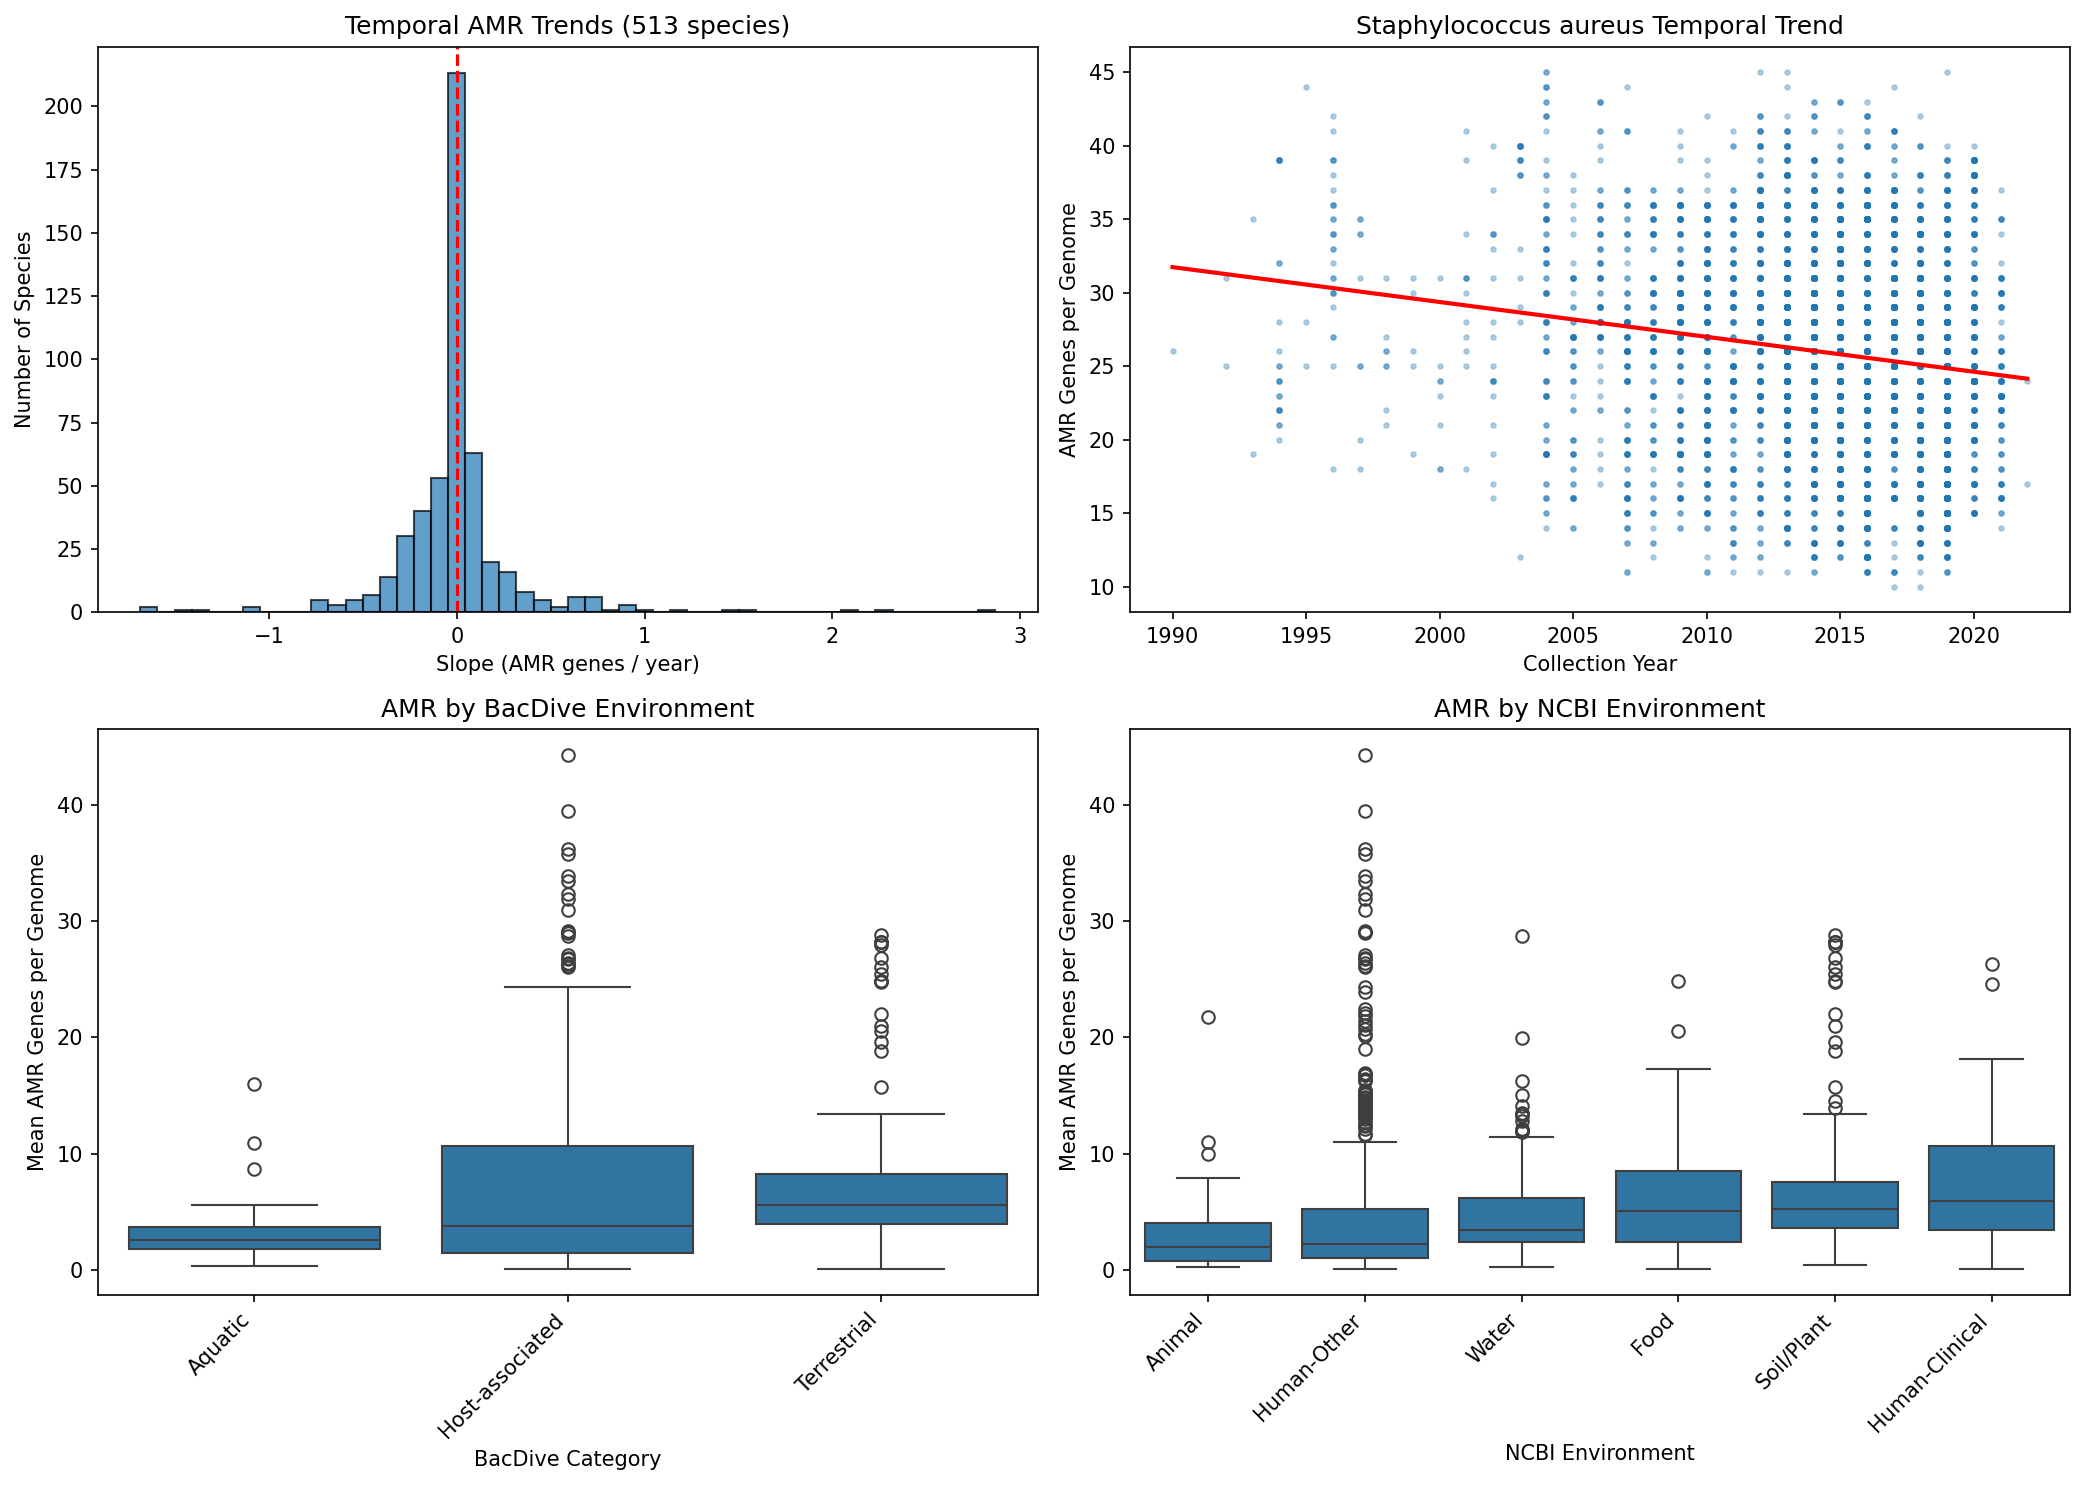

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 6a: Temporal slopes distribution
ax = axes[0, 0]
if len(temporal_df) > 0:
    ax.hist(temporal_df['slope'], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', ls='--')
    ax.set_xlabel('Slope (AMR genes / year)')
    ax.set_ylabel('Number of Species')
    ax.set_title(f'Temporal AMR Trends ({len(temporal_df)} species)')

# 6b: Case study temporal trend (S. aureus if available)
ax = axes[0, 1]
# Find a well-known species for case study
for target in ['Staphylococcus_aureus', 'Escherichia_coli', 'Klebsiella_pneumoniae']:
    match = dated[dated['species_id'].str.contains(target)]
    if len(match) >= 30:
        recent = match[match['year'] >= 1990]
        if len(recent) >= 20:
            ax.scatter(recent['year'], recent['amr_count'], alpha=0.3, s=5)
            # Add trend line
            z = np.polyfit(recent['year'], recent['amr_count'], 1)
            p = np.poly1d(z)
            years = np.linspace(recent['year'].min(), recent['year'].max(), 100)
            ax.plot(years, p(years), 'r-', linewidth=2)
            ax.set_xlabel('Collection Year')
            ax.set_ylabel('AMR Genes per Genome')
            ax.set_title(f"{target.replace('_', ' ')} Temporal Trend")
            break

# 6c: AMR by BacDive cat1
ax = axes[1, 0]
known = bridge[bridge['bacdive_cat1'] != 'Unknown'].dropna(subset=['mean_amr_per_genome'])
if len(known) > 0:
    order = known.groupby('bacdive_cat1')['mean_amr_per_genome'].median().sort_values().index
    sns.boxplot(data=known, x='bacdive_cat1', y='mean_amr_per_genome', order=order, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('BacDive Category')
    ax.set_ylabel('Mean AMR Genes per Genome')
    ax.set_title('AMR by BacDive Environment')

# 6d: AMR by NCBI env
ax = axes[1, 1]
known_ncbi = bridge[bridge['ncbi_env'] != 'Unknown'].dropna(subset=['mean_amr_per_genome'])
if len(known_ncbi) > 0:
    order_n = known_ncbi.groupby('ncbi_env')['mean_amr_per_genome'].median().sort_values().index
    sns.boxplot(data=known_ncbi, x='ncbi_env', y='mean_amr_per_genome', order=order_n, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('NCBI Environment')
    ax.set_ylabel('Mean AMR Genes per Genome')
    ax.set_title('AMR by NCBI Environment')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb06_temporal_bacdive.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("="*60)
print("NB06 SUMMARY")
print("="*60)
print(f"Genomes with temporal data: {len(dated)}")
print(f"Species with temporal regression: {len(temporal_df)}")
if len(temporal_df) > 0:
    sig_temp = temporal_df[temporal_df['fdr'] < 0.05]
    print(f"Significant trends: {len(sig_temp)} ({(sig_temp['slope']>0).sum()} increasing, {(sig_temp['slope']<0).sum()} decreasing)")
print(f"BacDive classified: {(bridge['bacdive_cat1'] != 'Unknown').sum()}/{len(bridge)}")
print(f"NCBI env classified: {(bridge['ncbi_env'] != 'Unknown').sum()}/{len(bridge)}")

NB06 SUMMARY
Genomes with temporal data: 106649
Species with temporal regression: 513
Significant trends: 0 (0 increasing, 0 decreasing)
BacDive classified: 484/1307
NCBI env classified: 1190/1307
